In [ ]:
import math
import random
import time
import matplotlib.pyplot as plt

In [ ]:
def caixeiro_viajante_aco(grafo, iteracoes, formigas, alfa, beta, evaporacao, Q, numero_cidades):
    melhor_rota = []
    distancia_min = float('inf')
    quantidade_iteracoes = 0

    for i in range(iteracoes):
        quantidade_iteracoes = i + 1

        # Caminhos das formigas

        rotas = []
        distancias = []
        for _ in range(formigas):
            cidade_atual = 0
            rota = [cidade_atual]
            visitadas = {cidade_atual}
            distancia_rota = 0.0

            for _ in range(numero_cidades - 1):
                proxima_cidade = selecionar_aresta(grafo, cidade_atual, visitadas, alfa, beta)

                for aresta in grafo[cidade_atual]:
                    if aresta['vizinho'] == proxima_cidade:
                        distancia_rota += aresta['distancia']
                        break

                rota.append(proxima_cidade)
                visitadas.add(proxima_cidade)
                cidade_atual = proxima_cidade

            for aresta in grafo[cidade_atual]:
                if aresta['vizinho'] == 0:
                    distancia_rota += aresta['distancia']
                    break

            rotas.append(rota)
            distancias.append(distancia_rota)

            if distancia_rota < distancia_min:
                distancia_min = distancia_rota
                melhor_rota = list(rota)


        # Teste para convergência das rotas obtidas:
        # Se todas as rotas forem iguais numa iteração, o algoritmo
        # para antes de ir até o final de todas as iterações.

        rota_teste = rotas[0]

        for i in range(len(rotas)):
            if rota_teste != rotas[i]:
                break

            if i == len(rotas) - 1:
                return melhor_rota, distancia_min, quantidade_iteracoes

        # Atualização de feromônio

        for vizinhos in grafo:
            for aresta in vizinhos:
                aresta['feromonio'] *= (1.0 - evaporacao)

        for i in range(formigas):
            rota_atual = rotas[i]
            distancia = distancias[i]

            feromonio_adicionado = Q / distancia

            for u in range(numero_cidades):
                x = rota_atual[u]

                if u == (numero_cidades - 1):
                    y = rota_atual[0]
                else:
                    y = rota_atual[u + 1]

                for aresta in grafo[x]:
                    if aresta['vizinho'] == y:
                        aresta['feromonio'] += feromonio_adicionado
                        break

                for aresta in grafo[y]:
                    if aresta['vizinho'] == x:
                        aresta['feromonio'] += feromonio_adicionado
                        break

    return melhor_rota, distancia_min, quantidade_iteracoes

In [ ]:
def selecionar_aresta(grafo, cidade_atual, visitadas, alfa, beta):
    caminhos_possiveis = grafo[cidade_atual]
    atratividades = []
    id_caminhos = []
    somatorio_atratividades = 0.0
    probabilidades = []

    for aresta in caminhos_possiveis:
        cidade = aresta['vizinho']
        if cidade not in visitadas:
            feromonio = aresta['feromonio']
            heuristica = aresta['heuristica']

            valor = (feromonio ** alfa) * (heuristica ** beta)

            atratividades.append(valor)
            id_caminhos.append(cidade)
            somatorio_atratividades += valor

    for atratividade in atratividades:
        probabilidades.append(atratividade / somatorio_atratividades)

    r = random.random()
    soma_cumulativa = 0.0

    for i in range(len(probabilidades)):
        soma_cumulativa += probabilidades[i]

        if r <= soma_cumulativa:
            return id_caminhos[i]

    return id_caminhos[len(id_caminhos) - 1]


---------------------------------------RESULTADOS---------------------------------------
Melhor tour encontrado : [0, 6, 5, 1, 2, 3, 4, 8, 12, 16, 15, 14, 13, 9, 10, 11, 7]
Custo total            : 328.28
Número de iterações    : 200
Tempo de execução      : 0.089s



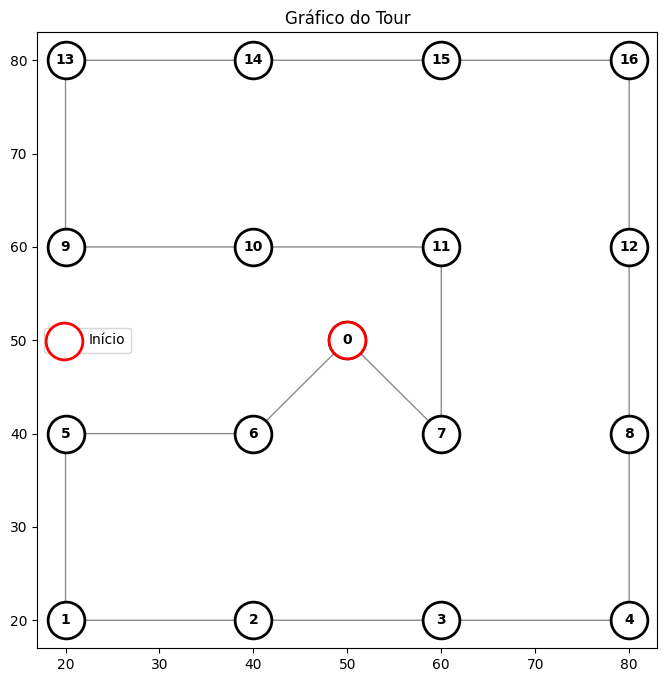

In [ ]:
def main():
    cidades = [
        (50, 50), (20, 20), (40, 20), (60, 20), (80, 20),
        (20, 40), (40, 40), (60, 40), (80, 40), (20, 60),
        (40, 60), (60, 60), (80, 60), (20, 80), (40, 80),
        (60, 80), (80, 80)
    ]

    numero_cidades = len(cidades)

    grafo = []
    for _ in range(numero_cidades):
        grafo.append([])

    for i in range(numero_cidades):
        for u in range(numero_cidades):
            if i != u:
                x1, y1 = cidades[i]
                x2, y2 = cidades[u]

                dist = math.sqrt((x1 - x2) ** 2 + (y1 - y2) ** 2)

                aresta = {
                    'vizinho': u,
                    'distancia': dist,
                    'feromonio': 1.0,
                    'heuristica': 1.0 / dist
                }

                grafo[i].append(aresta)


    tempo = time.time()

    iteracoes = 200
    formigas = 5
    alfa = 1.0
    beta = 1.0
    evaporacao = 0.4
    Q = 100

    rota, distancia, quantidade_iteracoes = caixeiro_viajante_aco(grafo, iteracoes, formigas, alfa, beta, evaporacao, Q, numero_cidades)

    tempo = time.time() - tempo

    print()
    print("=" * 88)
    print("-" * 39 + "RESULTADOS" + "-" * 39)
    print("=" * 88)
    print(f"Melhor tour encontrado : {rota}")
    print(f"Custo total            : {distancia:.2f}")
    print(f"Número de iterações    : {quantidade_iteracoes}")
    print(f"Tempo de execução      : {tempo:.3f}s")
    print("=" * 88)
    print()

    # Gráfico

    plt.figure(figsize=(8, 8))
    x_arestas = []
    x_vertices = []
    y_arestas = []
    y_vertices = []

    for id in rota:
        coord_x = cidades[id][0]
        coord_y = cidades[id][1]

        x_arestas.append(coord_x)
        y_arestas.append(coord_y)

    x_arestas.append(cidades[rota[0]][0])
    y_arestas.append(cidades[rota[0]][1])

    for v in cidades:
        x_vertices.append(v[0])
        y_vertices.append(v[1])

    plt.plot(x_arestas, y_arestas, color='gray', linestyle='-', linewidth=1, alpha=0.9, zorder=1)

    plt.scatter(x_vertices, y_vertices, facecolor='white', edgecolor='black', linewidth=2, s=700, zorder=2)

    plt.scatter(x_vertices[0], y_vertices[0], facecolor='white', edgecolor='red', linewidth=2, s=700, label='Início', zorder=3)

    for i in range(len(cidades)):
        plt.text(x_vertices[i], y_vertices[i], str(i), color='black', ha='center', va='center', fontweight='bold', zorder=4)

    plt.legend()
    plt.title("Gráfico do Tour")
    plt.grid(False)
    plt.show()

main()